## Подготовка

In [675]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [676]:
data = pd.read_csv('data/r5_eda.csv')

In [677]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   int64  
 6   total_sulfur_dioxide  6497 non-null   int64  
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
dtypes: float64(9), int64(3)
memory usage: 609.2 KB


In [678]:
y = data['quality']
X = data.drop('quality', axis=1)

In [679]:
from sklearn.model_selection import train_test_split

In [680]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [681]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((5197, 11), (5197,), (1300, 11), (1300,))

In [682]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet

## Реализация пользовательских функций

In [683]:
import numpy as np

$ MAE=\frac{1}{m}{\sum_{i=1}^{m}|y_i-\hat{y}_i|} $

In [684]:
def mae_metrick(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

$ MSE=\frac{1}{m}{\sum_{i=1}^{m}(y_i-\hat{y}_i)^2} $

In [685]:
def mse_metrick(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

$ RMSE=\sqrt{\frac{1}{m}{\sum_{i=1}^{m}(y_i-\hat{y}_i)^2}} $

In [686]:
def rmse_metrick(y_true, y_pred):
    return np.sqrt(mse_metrick(y_true, y_pred))

$ MAPE=\frac{1}{m}\sum_{i=1}^{m}{|\frac{y_i-\hat{y}_i}{y_i}|} $

In [687]:
def mape_metrick(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true))

$ R^2=\frac{MSE}{\frac{1}{m}{\sum_{i=1}^{m}(y_i-\bar{y})^2}} $. $\bar{y}$ - среднее значение целевого признака.

In [688]:
def r2_score_metrick(y_true, y_pred):
    denominator = np.sum((y_true - np.mean(y_true)) ** 2)
    numerator = mse_metrick(y_true, y_pred)
    return numerator / denominator

Вспомогательные

In [689]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from math import sqrt

In [690]:
def sklearn_metrick_printer(y_true, y_pred):
    print(f'MAE: {mean_absolute_error(y_true, y_pred)}')
    print(f'MSE: {mean_squared_error(y_true, y_pred)}')
    print(f'RMSE: {sqrt(mean_squared_error(y_true, y_pred))}')
    print(f'MAPE: {mean_absolute_percentage_error(y_true, y_pred)}')
    print(f'R^2: {r2_score(y_true, y_pred)}')

In [691]:
def metrick_printer(y_true, y_pred):
    print(f'MAE: {mae_metrick(y_true, y_pred)}')
    print(f'MSE: {mse_metrick(y_true, y_pred)}')
    print(f'RMSE: {rmse_metrick(y_true, y_pred)}')
    print(f'MAPE: {mape_metrick(y_true, y_pred)}')
    print(f'R^2: {r2_score_metrick(y_true, y_pred)}')

In [692]:
def return_metricks(y_true, y_pred):
    return [mean_absolute_error(y_true, y_pred), mean_squared_error(y_true, y_pred), sqrt(mean_squared_error(
        y_true, y_pred)), mean_absolute_percentage_error(y_true, y_pred), r2_score(y_true, y_pred)]

## Простая линейная регрессия

In [693]:
lr = LinearRegression().fit(X_train, y_train)
y_pred = lr.predict(X_test)

### Метрики

In [694]:
sklearn_metrick_printer(y_test, y_pred)

MAE: 0.5692308819469136
MSE: 0.5472730672262246
RMSE: 0.7397790664963592
MAPE: 0.1030395118411378
R^2: 0.25723220793166734


In [695]:
metrick_printer(y_test, y_pred)

MAE: 0.5692308819469136
MSE: 0.5472730672262246
RMSE: 0.7397790664963592
MAPE: 0.1030395118411378
R^2: 0.0005713598400525636


In [696]:
len(lr.coef_)
lr.coef_

array([ 7.75857475e-02, -1.37789103e+00, -1.30673611e-01,  4.37021673e-02,
       -4.04923607e-01,  5.84735007e-03, -2.46391157e-03, -5.95596063e+01,
        4.85445285e-01,  6.89389802e-01,  2.66099551e-01])

## Линейная регрессия с L1-регуляризацией

In [ ]:
lasso = Lasso(alpha=0.5).fit(X_train, y_train)
y_pred = lasso.predict(X_test)

### Метрики

In [698]:
sklearn_metrick_printer(y_test, y_pred)

MAE: 0.6711499185443626
MSE: 0.7288683948057746
RMSE: 0.8537378958472996
MAPE: 0.12206480246388231
R^2: 0.010768114239236959


In [699]:
metrick_printer(y_test, y_pred)

MAE: 0.6711499185443626
MSE: 0.7288683948057746
RMSE: 0.8537378958472996
MAPE: 0.12206480246388231
R^2: 0.0007609476044313561


In [700]:
lasso.coef_

array([-0.        , -0.        ,  0.        , -0.        , -0.        ,
        0.00456848, -0.00144089, -0.        ,  0.        ,  0.        ,
        0.        ])

### Подбор гиперпараметров

In [701]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
import numpy as np
import optuna

GridSearchCV

In [702]:
param_grid = {'alpha': [0.001, 0.01, 0.1, 0.5, 1, 10]}

In [703]:
grid = GridSearchCV(Lasso(), param_grid, cv=5, scoring='r2')
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': [0.001, 0.01, 0.1, 0.5, 1, 10]},
             scoring='r2')

In [704]:
print("Best alpha:", grid.best_params_['alpha'])
print("Best R^2:", grid.best_score_)

Best alpha: 0.001
Best R^2: 0.2918484461820847


RandomizedSearchCV

In [705]:
param_dist = {'alpha': np.logspace(-4, 1, 100)}

In [706]:
random_search = RandomizedSearchCV(
    Lasso(), param_dist, n_iter=20, cv=5, scoring='r2', random_state=42)
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=Lasso(), n_iter=20,
                   param_distributions={'alpha': array([1.00000000e-04, 1.12332403e-04, 1.26185688e-04, 1.41747416e-04,
       1.59228279e-04, 1.78864953e-04, 2.00923300e-04, 2.25701972e-04,
       2.53536449e-04, 2.84803587e-04, 3.19926714e-04, 3.59381366e-04,
       4.03701726e-04, 4.53487851e-04, 5.09413801e-04, 5.72236766e-04,
       6.42807312e-04, 7.22080...
       6.89261210e-01, 7.74263683e-01, 8.69749003e-01, 9.77009957e-01,
       1.09749877e+00, 1.23284674e+00, 1.38488637e+00, 1.55567614e+00,
       1.74752840e+00, 1.96304065e+00, 2.20513074e+00, 2.47707636e+00,
       2.78255940e+00, 3.12571585e+00, 3.51119173e+00, 3.94420606e+00,
       4.43062146e+00, 4.97702356e+00, 5.59081018e+00, 6.28029144e+00,
       7.05480231e+00, 7.92482898e+00, 8.90215085e+00, 1.00000000e+01])},
                   random_state=42, scoring='r2')

In [707]:
print("Best alpha:", random_search.best_params_['alpha'])
print("Best R^2:", random_search.best_score_)

Best alpha: 0.0001
Best R^2: 0.29261956453573035


Фреймворк Optuna

In [708]:
def objective(trial):
    alpha = trial.suggest_loguniform('alpha', 1e-4, 10.0)
    model = Lasso(alpha=alpha)
    score = cross_val_score(model, X_train, y_train, scoring='r2', cv=5).mean()
    return score

In [709]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

[I 2025-04-24 17:04:33,936] A new study created in memory with name: no-name-4d01c292-b3e3-4708-b8b6-0ac9261ba678
C:\Users\andre\AppData\Local\Temp\ipykernel_12300\1532896469.py:2: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 1e-4, 10.0)
[I 2025-04-24 17:04:33,957] Trial 0 finished with value: 0.28882412743166636 and parameters: {'alpha': 0.00402857049806523}. Best is trial 0 with value: 0.28882412743166636.
C:\Users\andre\AppData\Local\Temp\ipykernel_12300\1532896469.py:2: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 1e-4, 10.0)
[I 2025-04-24 17:04:33,973] Trial 1 finished with value:

In [710]:
print("Best alpha:", study.best_params['alpha'])
print("Best R^2:", study.best_value)

Best alpha: 0.00010003572542453202
Best R^2: 0.29261957368831315


Сравнение гиперпараметров

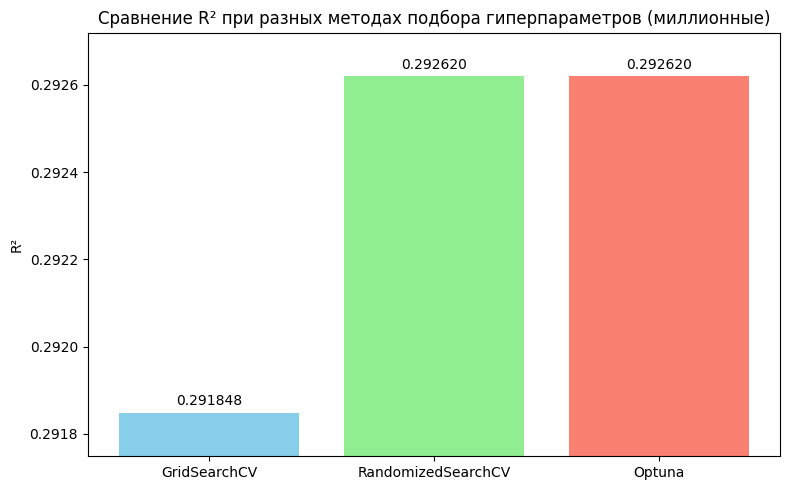

In [711]:
models = ['GridSearchCV', 'RandomizedSearchCV', 'Optuna']

r2_scores = [grid.best_score_, random_search.best_score_, study.best_value]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, r2_scores, color=[
              'skyblue', 'lightgreen', 'salmon'])

ax.set_ylabel('R²')
ax.set_title(
    'Сравнение R² при разных методах подбора гиперпараметров (миллионные)')

margin = 0.0001
y_min = min(r2_scores) - margin
y_max = max(r2_scores) + margin

ax.set_ylim(y_min, y_max)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.6f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Обучение с наилучшим гиперпараметром

In [ ]:
lasso_best = Lasso(alpha=0.0001).fit(X_train, y_train)
y_pred_new = lasso_best.predict(X_test)

### Метрики с наилучшим гиперпараметром

In [713]:
sklearn_metrick_printer(y_test, y_pred_new)

MAE: 0.5705774491025021
MSE: 0.5485772263113597
RMSE: 0.7406599937294843
MAPE: 0.10324240020299787
R^2: 0.25546218228600315


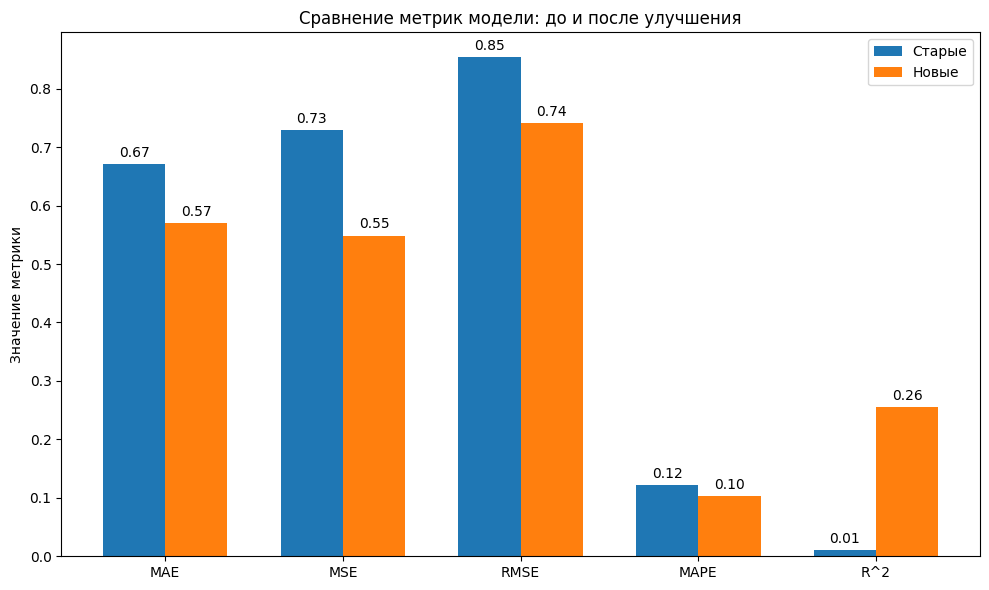

In [714]:
metrics = ['MAE', 'MSE', 'RMSE', 'MAPE', 'R^2']

old_values = return_metricks(y_test, y_pred)

new_values = return_metricks(y_test, y_pred_new)

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, old_values, width, label='Старые')
bars2 = ax.bar(x + width/2, new_values, width, label='Новые')

ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение метрик модели: до и после улучшения')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()


def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')


add_labels(bars1)
add_labels(bars2)

plt.tight_layout()
plt.show()

C:\Users\andre\AppData\Local\Temp\ipykernel_12300\2118410706.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(y_test, hist=False, color='Red', label='Actual weight')
C:\Users\andre\AppData\Local\Temp\ipykernel_12300\2118410706.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns

<Axes: xlabel='quality', ylabel='Density'>

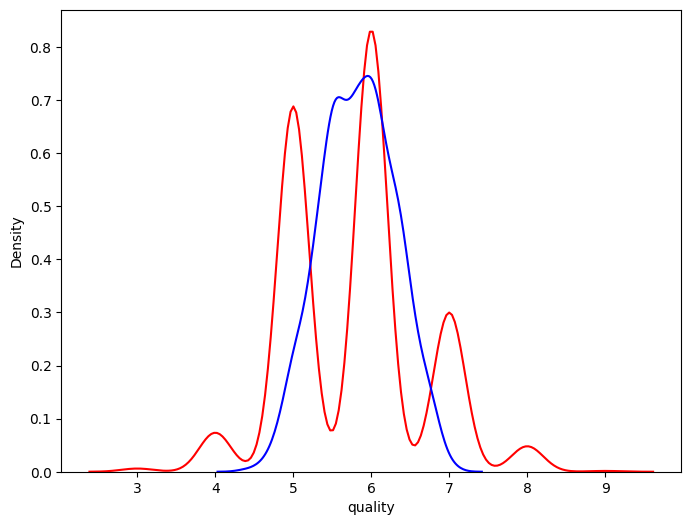

In [715]:
plt.figure(figsize=(8, 6))

ax1 = sns.distplot(y_test, hist=False, color='Red', label='Actual weight')
sns.distplot(y_pred_new, hist=False, color='Blue',
             ax=ax1, label='Predicted weight')

## Линейная регрессия с L2-регуляризацией

In [ ]:
ridge = Ridge(alpha=0.5).fit(X_train, y_train)
y_pred = ridge.predict(X_test)

### Метрики

In [717]:
sklearn_metrick_printer(y_test, y_pred)

MAE: 0.5704637905334105
MSE: 0.5485079712735792
RMSE: 0.7406132400069413
MAPE: 0.1032232241661367
R^2: 0.2555561763350117


In [718]:
metrick_printer(y_test, y_pred)

MAE: 0.5704637905334105
MSE: 0.5485079712735792
RMSE: 0.7406132400069413
MAPE: 0.1032232241661367
R^2: 0.0005726490951269141


In [ ]:
len(ridge.coef_)
ridge.coef_

array([ 0.01699788, -1.50323053, -0.12526835,  0.02200793, -0.67151705,
        0.00585591, -0.00221427, -0.31174146,  0.19741817,  0.55243697,
        0.33626279])

### Подбор гиперпараметров

GridSearchCV

In [720]:
param_grid = {'alpha': [0.001, 0.01, 0.1, 0.5, 1, 10, 100]}

In [721]:
grid = GridSearchCV(Ridge(), param_grid, cv=5, scoring='r2')
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.001, 0.01, 0.1, 0.5, 1, 10, 100]},
             scoring='r2')

In [722]:
print("Best alpha:", grid.best_params_['alpha'])
print("Best R^2:", grid.best_score_)

Best alpha: 0.001
Best R^2: 0.29437364304201497


RandomizedSearchCV

In [723]:
param_dist = {'alpha': np.logspace(-4, 2, 100)}

In [724]:
random_search = RandomizedSearchCV(Ridge(), param_distributions=param_dist, n_iter=20, cv=5,
                                   scoring='r2', random_state=42)
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=Ridge(), n_iter=20,
                   param_distributions={'alpha': array([1.00000000e-04, 1.14975700e-04, 1.32194115e-04, 1.51991108e-04,
       1.74752840e-04, 2.00923300e-04, 2.31012970e-04, 2.65608778e-04,
       3.05385551e-04, 3.51119173e-04, 4.03701726e-04, 4.64158883e-04,
       5.33669923e-04, 6.13590727e-04, 7.05480231e-04, 8.11130831e-04,
       9.32603347e-04, 1.07226...
       4.03701726e+00, 4.64158883e+00, 5.33669923e+00, 6.13590727e+00,
       7.05480231e+00, 8.11130831e+00, 9.32603347e+00, 1.07226722e+01,
       1.23284674e+01, 1.41747416e+01, 1.62975083e+01, 1.87381742e+01,
       2.15443469e+01, 2.47707636e+01, 2.84803587e+01, 3.27454916e+01,
       3.76493581e+01, 4.32876128e+01, 4.97702356e+01, 5.72236766e+01,
       6.57933225e+01, 7.56463328e+01, 8.69749003e+01, 1.00000000e+02])},
                   random_state=42, scoring='r2')

In [725]:
print("Best alpha:", random_search.best_params_['alpha'])
print("Best R^2:", random_search.best_score_)

Best alpha: 0.0001747528400007683
Best R^2: 0.2944916338843959


Фреймворк Optuna

In [726]:
def objective(trial):
    alpha = trial.suggest_loguniform('alpha', 1e-4, 100.0)
    model = Ridge(alpha=alpha)
    score = cross_val_score(model, X_train, y_train, scoring='r2', cv=5).mean()
    return score

In [727]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

[I 2025-04-24 17:04:35,359] A new study created in memory with name: no-name-bbc4d41a-4262-431d-b611-ab6129830708
C:\Users\andre\AppData\Local\Temp\ipykernel_12300\1837225706.py:2: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 1e-4, 100.0)
[I 2025-04-24 17:04:35,384] Trial 0 finished with value: 0.29268773089103445 and parameters: {'alpha': 0.19295651549940543}. Best is trial 0 with value: 0.29268773089103445.
C:\Users\andre\AppData\Local\Temp\ipykernel_12300\1837225706.py:2: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 1e-4, 100.0)
[I 2025-04-24 17:04:35,402] Trial 1 finished with valu

In [728]:
print("Best alpha:", study.best_params['alpha'])
print("Best R^2:", study.best_value)

Best alpha: 0.00024273799477784514
Best R^2: 0.2944923948180192


Сравнение гиперпараметров

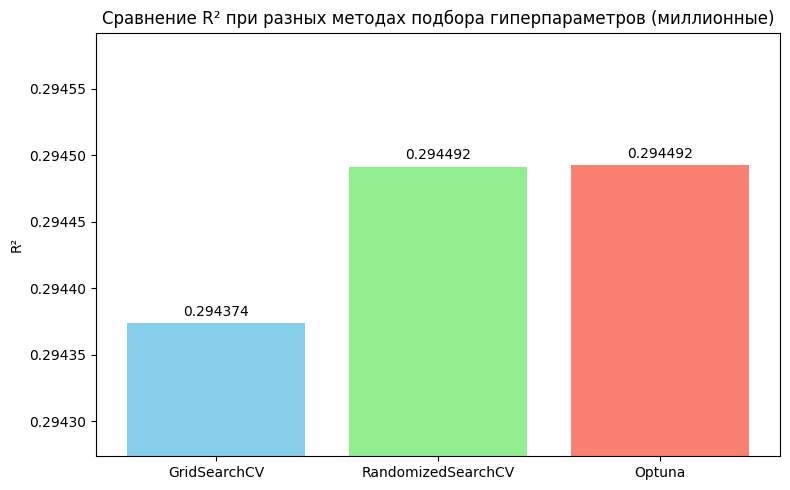

In [729]:
models = ['GridSearchCV', 'RandomizedSearchCV', 'Optuna']

r2_scores = [grid.best_score_, random_search.best_score_, study.best_value]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, r2_scores, color=[
              'skyblue', 'lightgreen', 'salmon'])

ax.set_ylabel('R²')
ax.set_title(
    'Сравнение R² при разных методах подбора гиперпараметров (миллионные)')

margin = 0.0001
y_min = min(r2_scores) - margin
y_max = max(r2_scores) + margin

ax.set_ylim(y_min, y_max)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.6f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Обучение с наилучшим гиперпараметром

In [ ]:
ridge_best = Ridge(alpha=0.0001).fit(X_train, y_train)
y_pred_new = ridge_best.predict(X_test)

### Метрики с наилучшим гиперпараметром

In [731]:
sklearn_metrick_printer(y_test, y_pred_new)

MAE: 0.5691984590422356
MSE: 0.5472125866373697
RMSE: 0.7397381878998608
MAPE: 0.10303298570543795
R^2: 0.25731429315774


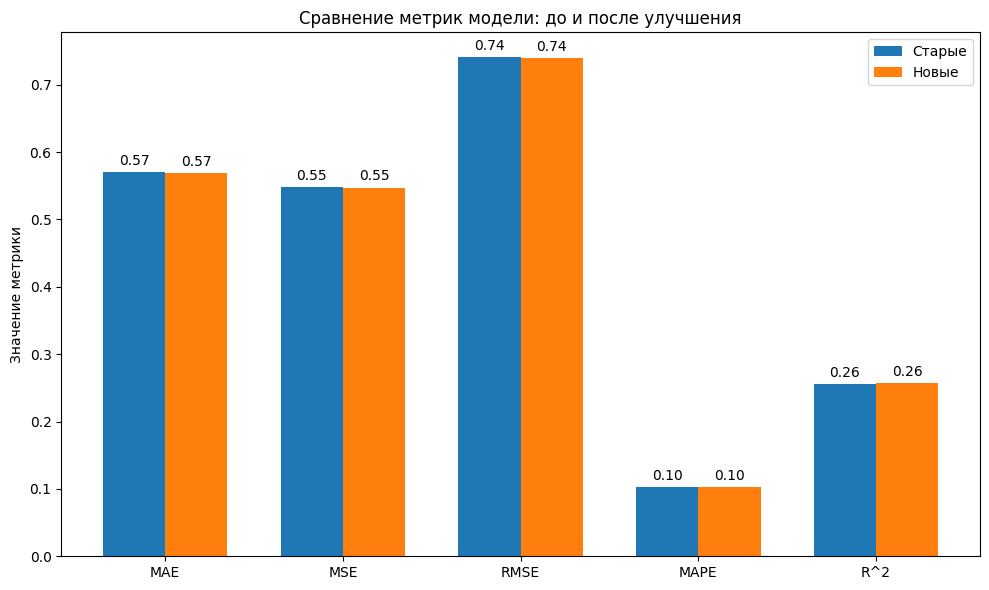

In [732]:
metrics = ['MAE', 'MSE', 'RMSE', 'MAPE', 'R^2']

old_values = return_metricks(y_test, y_pred)

new_values = return_metricks(y_test, y_pred_new)

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, old_values, width, label='Старые')
bars2 = ax.bar(x + width/2, new_values, width, label='Новые')

ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение метрик модели: до и после улучшения')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()


def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')


add_labels(bars1)
add_labels(bars2)

plt.tight_layout()
plt.show()

C:\Users\andre\AppData\Local\Temp\ipykernel_12300\2118410706.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(y_test, hist=False, color='Red', label='Actual weight')
C:\Users\andre\AppData\Local\Temp\ipykernel_12300\2118410706.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns

<Axes: xlabel='quality', ylabel='Density'>

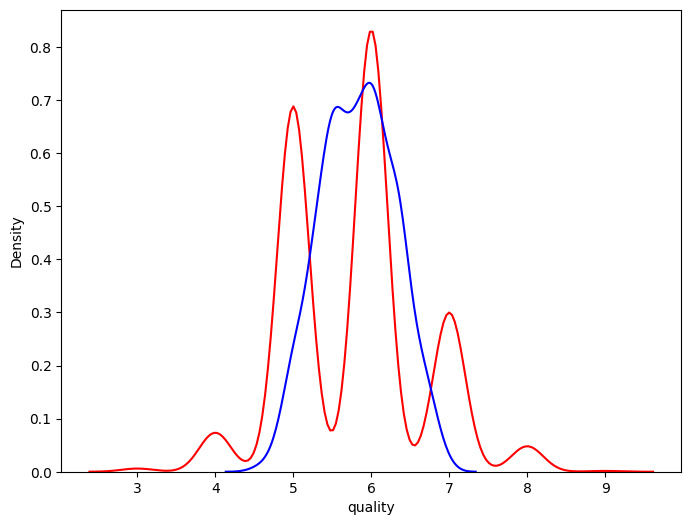

In [733]:
plt.figure(figsize=(8, 6))

ax1 = sns.distplot(y_test, hist=False, color='Red', label='Actual weight')
sns.distplot(y_pred_new, hist=False, color='Blue',
             ax=ax1, label='Predicted weight')

## Линейная регрессия с двумя регуляризаторами

In [734]:
base_elastic_model = ElasticNet(max_iter=100000, alpha=1.0, l1_ratio=0.5)
base_elastic_model.fit(X_train, y_train)
y_pred = base_elastic_model.predict(X_test)

### Метрики

In [735]:
sklearn_metrick_printer(y_test, y_pred)

MAE: 0.6711725729249153
MSE: 0.7288927582434603
RMSE: 0.8537521644150955
MAPE: 0.12206907402781259
R^2: 0.010735047790510044


In [736]:
metrick_printer(y_test, y_pred)

MAE: 0.6711725729249153
MSE: 0.7288927582434603
RMSE: 0.8537521644150955
MAPE: 0.12206907402781259
R^2: 0.0007609730401611461


In [737]:
len(base_elastic_model.coef_)
base_elastic_model.coef_

array([-0.       , -0.       ,  0.       , -0.       , -0.       ,
        0.0045518, -0.0014369, -0.       ,  0.       ,  0.       ,
        0.       ])

### Подбор гиперпараметров

GridSearchCV

In [738]:
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

In [739]:
grid = GridSearchCV(
    ElasticNet(max_iter=100000),
    param_grid,
    scoring='r2',
    cv=5
)
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=ElasticNet(max_iter=100000),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10],
                         'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]},
             scoring='r2')

In [740]:
print("Best params:", grid.best_params_)
print("Best R^2:", grid.best_score_)

Best params: {'alpha': 0.001, 'l1_ratio': 0.1}
Best R^2: 0.29238875965912137


RandomizedSearchCV

In [741]:
param_dist = {
    'alpha': np.logspace(-4, 1, 100),
    'l1_ratio': np.linspace(0.1, 0.9, 9)
}

In [742]:
random_search = RandomizedSearchCV(
    ElasticNet(max_iter=100000),
    param_distributions=param_dist,
    n_iter=30,
    scoring='r2',
    cv=5,
    random_state=42
)
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=ElasticNet(max_iter=100000), n_iter=30,
                   param_distributions={'alpha': array([1.00000000e-04, 1.12332403e-04, 1.26185688e-04, 1.41747416e-04,
       1.59228279e-04, 1.78864953e-04, 2.00923300e-04, 2.25701972e-04,
       2.53536449e-04, 2.84803587e-04, 3.19926714e-04, 3.59381366e-04,
       4.03701726e-04, 4.53487851e-04, 5.09413801e-04, 5.72236766e-04,
       6....
       1.09749877e+00, 1.23284674e+00, 1.38488637e+00, 1.55567614e+00,
       1.74752840e+00, 1.96304065e+00, 2.20513074e+00, 2.47707636e+00,
       2.78255940e+00, 3.12571585e+00, 3.51119173e+00, 3.94420606e+00,
       4.43062146e+00, 4.97702356e+00, 5.59081018e+00, 6.28029144e+00,
       7.05480231e+00, 7.92482898e+00, 8.90215085e+00, 1.00000000e+01]),
                                        'l1_ratio': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])},
                   random_state=42, scoring='r2')

In [743]:
print("Best params:", random_search.best_params_)
print("Best R^2:", random_search.best_score_)

Best params: {'l1_ratio': np.float64(0.1), 'alpha': np.float64(0.00025353644939701115)}
Best R^2: 0.2926443777518752


Фреймворк Optuna

In [744]:
def objective(trial):
    alpha = trial.suggest_loguniform('alpha', 1e-4, 10.0)
    l1_ratio = trial.suggest_uniform('l1_ratio', 0.1, 0.9)
    model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=100000)
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='r2').mean()
    return score

In [745]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=40)

[I 2025-04-24 17:04:37,244] A new study created in memory with name: no-name-eccd4d68-6726-4b64-a007-8ee81724cafd
C:\Users\andre\AppData\Local\Temp\ipykernel_12300\4049124632.py:2: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 1e-4, 10.0)
C:\Users\andre\AppData\Local\Temp\ipykernel_12300\4049124632.py:3: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  l1_ratio = trial.suggest_uniform('l1_ratio', 0.1, 0.9)
[I 2025-04-24 17:04:37,268] Trial 0 finished with value: 0.07861868242347939 and parameters: {'alpha': 0.6566071041270839, 'l1_ratio': 0.5504418747697122}. Best is trial 0 with value: 0.07861868242347939.
C:\Users\andre\AppData\Local\Temp\ipykerne

In [746]:
print("Best params:", study.best_params)
print("Best R^2:", study.best_value)

Best params: {'alpha': 0.00010063749195564101, 'l1_ratio': 0.694667766657544}
Best R^2: 0.2926307453873848


Сравнение гиперпараметров

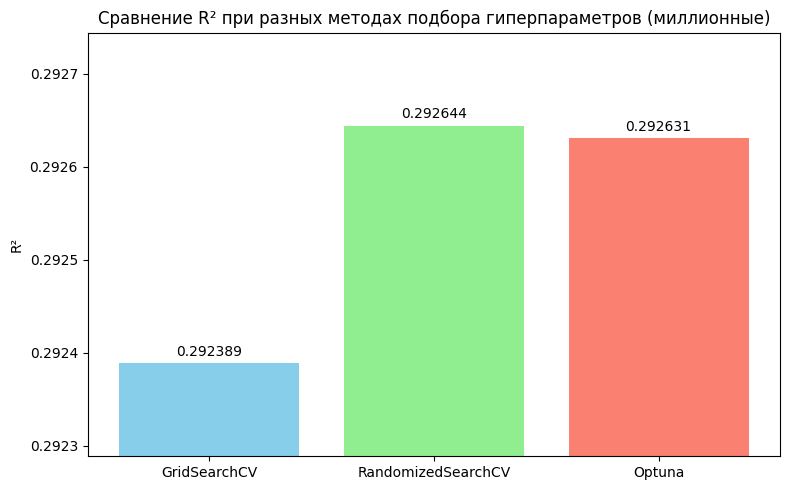

In [747]:
models = ['GridSearchCV', 'RandomizedSearchCV', 'Optuna']

r2_scores = [grid.best_score_, random_search.best_score_, study.best_value]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, r2_scores, color=[
              'skyblue', 'lightgreen', 'salmon'])

ax.set_ylabel('R²')
ax.set_title(
    'Сравнение R² при разных методах подбора гиперпараметров (миллионные)')

margin = 0.0001
y_min = min(r2_scores) - margin
y_max = max(r2_scores) + margin

ax.set_ylim(y_min, y_max)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.6f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Обучение с наилучшим гиперпараметром

In [ ]:
base_elastic_model = ElasticNet(max_iter=100000, alpha=0.000253, l1_ratio=0.1)
base_elastic_model.fit(X_train, y_train)
y_pred_new = base_elastic_model.predict(X_test)

## Полиномиальная регрессия

In [ ]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

In [ ]:
polynomial_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('reg', LinearRegression())
])

In [ ]:
polynomial_model.fit(X_train, y_train)

In [ ]:
y_pred = polynomial_model.predict(X_test)

### Метрики

In [ ]:
sklearn_metrick_printer(y_test, y_pred)

In [ ]:
metrick_printer(y_test, y_pred)

In [ ]:
len(base_elastic_model.coef_)
base_elastic_model.coef_

### Подбор гиперпараметров

GridSearchCV

In [ ]:
pipeline = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('reg', ElasticNet(max_iter=100000))
])

In [ ]:
param_grid = {
    'poly__degree': [2, 3],
    'reg__alpha': [0.001, 0.01, 0.1, 1],
    'reg__l1_ratio': [0.2, 0.5, 0.8]
}

In [ ]:
# grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='r2')
# grid.fit(X_train, y_train)

In [ ]:
# print("Best params:", grid.best_params_)
# print("Best R^2:", grid.best_score_)

RandomizedSearchCV

In [ ]:
param_dist = {
    'poly__degree': [2, 3],
    'reg__alpha': np.logspace(-4, 1, 100),
    'reg__l1_ratio': np.linspace(0.1, 0.9, 9)
}

In [ ]:
# random_search = RandomizedSearchCV(
#     pipeline, param_distributions=param_dist,
#     n_iter=30, cv=5, scoring='r2', random_state=42
# )
# random_search.fit(X_train, y_train)

In [ ]:
# print("Best params:", random_search.best_params_)
# print("Best R^2:", random_search.best_score_)

Фреймворк Optuna

In [ ]:
# def objective(trial):
#     degree = trial.suggest_int('degree', 2, 3)
#     alpha = trial.suggest_loguniform('alpha', 1e-4, 10.0)
#     l1_ratio = trial.suggest_uniform('l1_ratio', 0.1, 0.9)

#     pipeline = Pipeline([
#         ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
#         ('scaler', StandardScaler()),
#         ('reg', ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=100000))
#     ])

#     score = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2').mean()
#     return score

In [ ]:
# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=40)

In [ ]:
# print("Best params:", study.best_params)
# print("Best R^2:", study.best_value)